In [1]:
import os
import io
import ssl
import certifi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from PIL import Image

# Fix macOS SSL certificate verification for cartopy downloads
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

In [2]:
os.makedirs("outputs/figures", exist_ok=True)

df_raw = pd.read_csv("../data/processed/nigeria_acled.csv")
print(f"Loaded {len(df_raw):,} rows")
print(df_raw[["actor1", "event_date", "location", "latitude", "longitude"]].head())

Loaded 41,670 rows
                                   actor1  event_date  location  latitude  \
0                    Protesters (Nigeria)  2018-11-15     Abuja    9.0833   
1                    Protesters (Nigeria)  2018-11-13   Yenagoa    4.9247   
2  Bassa Kwomu Communal Militia (Nigeria)  2018-11-12     Oguma    7.8981   
3      Unidentified Armed Group (Nigeria)  2018-09-12  Badarawa   13.0045   
4                    Protesters (Nigeria)  2018-08-27     Lagos    6.4531   

   longitude  
0     7.5333  
1     6.2642  
2     7.0524  
3     6.5234  
4     3.3958  


## Analysis 1 — Animated GIF: Boko Haram Events by City (Monthly)

In [3]:
# ── Filter Boko Haram ─────────────────────────────────────────────────────────
bh = df_raw[df_raw["actor1"].str.contains("Boko Haram", case=False, na=False)].copy()
print(f"Boko Haram events: {len(bh):,}")

# ── Parse date → month_year period ───────────────────────────────────────────
bh["event_date"] = pd.to_datetime(bh["event_date"], format="mixed", dayfirst=True)
bh["month_year"] = bh["event_date"].dt.to_period("M")

# ── Aggregate to city level per month_year ────────────────────────────────────
city_month = (
    bh.groupby(["month_year", "location", "latitude", "longitude"])
    .size()
    .reset_index(name="n_events")
)

# ── Sort periods chronologically ──────────────────────────────────────────────
periods = sorted(city_month["month_year"].unique())
print(f"Time range: {periods[0]} to {periods[-1]}  ({len(periods)} months)")

# ── Consistent colormap / norm across all frames ──────────────────────────────
max_events = city_month["n_events"].max()
cmap = plt.get_cmap("YlOrRd")
norm = mcolors.Normalize(vmin=1, vmax=max_events)
NIGERIA_EXTENT = [2.5, 15.0, 4.0, 14.0]  # [lon_min, lon_max, lat_min, lat_max]

# ── Build one frame per month ─────────────────────────────────────────────────
frames = []
for period in periods:
    df_p = city_month[city_month["month_year"] == period]

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent(NIGERIA_EXTENT, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="#f5f5dc", edgecolor="none")
    ax.add_feature(cfeature.OCEAN, facecolor="#c8e6f5", edgecolor="none")
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="#555555")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#555555")

    ax.scatter(
        df_p["longitude"].values, df_p["latitude"].values,
        s=np.sqrt(df_p["n_events"].values) * 20,
        c=cmap(norm(df_p["n_events"].values)),
        transform=ccrs.PlateCarree(),
        alpha=0.85, edgecolors="black", linewidths=0.4, zorder=5,
    )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label("Events in month", fontsize=9)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray",
                      alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    ax.set_title(f"Boko Haram Events — {period}",
                 fontsize=13, fontweight="bold", pad=10)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=80, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    frames.append(Image.open(buf).copy())

# ── Save animated GIF ─────────────────────────────────────────────────────────
gif_path = "outputs/figures/02_actor_analysis_boko_haram_city_monthly.gif"
if frames:
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        loop=0,
        duration=500,
        optimize=False,
    )
    print(f"GIF saved to {gif_path} ({len(frames)} frames)")
else:
    print("No frames generated — check the Boko Haram filter.")

Boko Haram events: 2,497
Time range: 2009-07 to 2025-12  (182 months)


GIF saved to outputs/figures/02_actor_analysis_boko_haram_city_monthly.gif (182 frames)


## Analysis 2 — Static Map: Boko Haram & Militia Event Concentration

Boko Haram: 2,497 events across 486 cities  |  top city: Maiduguri (388)
Militia: 9,618 events across 2776 cities  |  top city: Dutsin Ma (90)


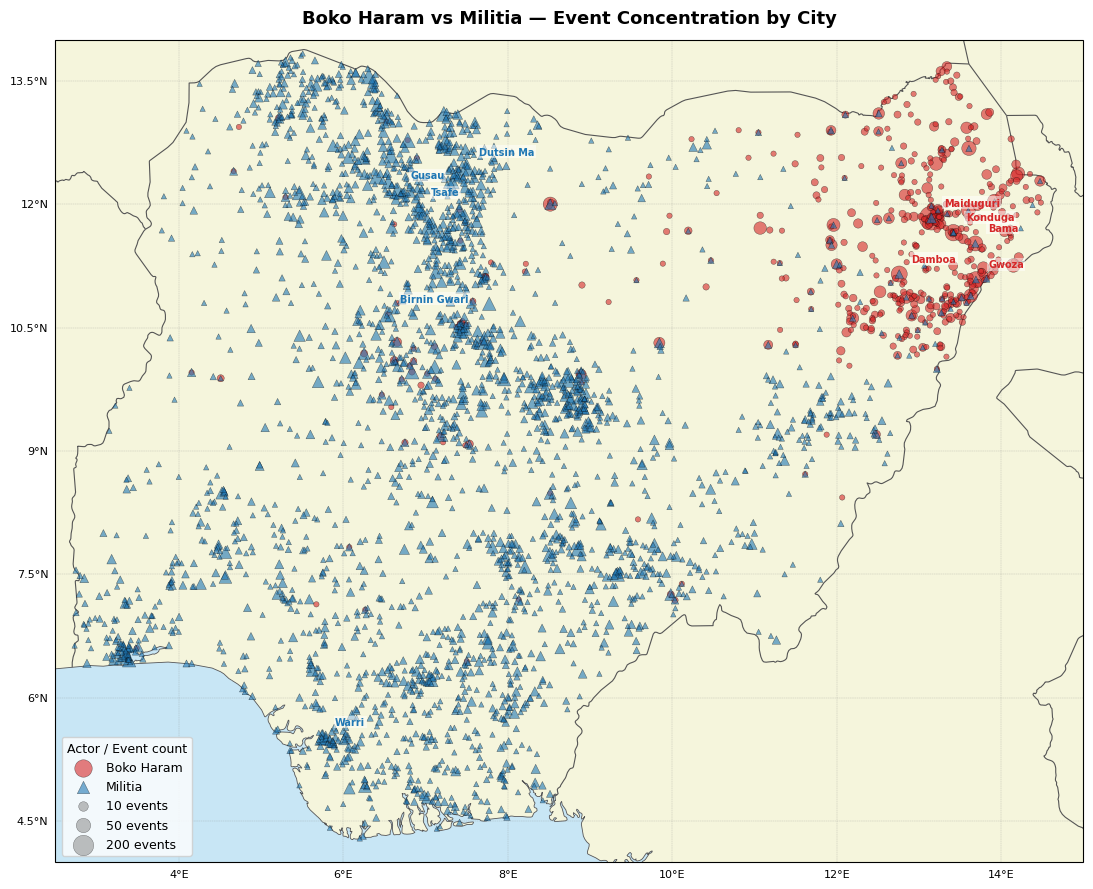

Saved to outputs/figures/02_actor_analysis_boko_haram_militia_concentration.png


In [4]:
# ── Define actors and their colours ──────────────────────────────────────────
ACTORS = {
    "Boko Haram": {"pattern": "Boko Haram", "color": "#d62728", "marker": "o"},
    "Militia":    {"pattern": "Militia",     "color": "#1f77b4", "marker": "^"},
}

# ── Aggregate per actor, per city ─────────────────────────────────────────────
actor_city = {}
for label, cfg in ACTORS.items():
    subset = df_raw[df_raw["actor1"].str.contains(cfg["pattern"], case=False, na=False)]
    agg = (
        subset.groupby(["location", "latitude", "longitude"])
        .size()
        .reset_index(name="n_events")
        .sort_values("n_events", ascending=False)
        .reset_index(drop=True)
    )
    actor_city[label] = agg
    print(f"{label}: {len(subset):,} events across {len(agg)} cities  |  top city: {agg.iloc[0]['location']} ({agg.iloc[0]['n_events']})")

# ── Shared size scale (sqrt of events, capped for legibility) ─────────────────
all_counts = pd.concat([d["n_events"] for d in actor_city.values()])
max_count  = all_counts.max()
def scale(s): return np.sqrt(s / max_count) * 300   # same scale across actors

# ── Plot ──────────────────────────────────────────────────────────────────────
NIGERIA_EXTENT = [2.5, 15.0, 4.0, 14.0]

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent(NIGERIA_EXTENT, crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND,      facecolor="#f5f5dc", edgecolor="none")
ax.add_feature(cfeature.OCEAN,     facecolor="#c8e6f5", edgecolor="none")
ax.add_feature(cfeature.BORDERS,   linewidth=0.8, edgecolor="#555555")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#555555")

for label, cfg in ACTORS.items():
    agg = actor_city[label]
    ax.scatter(
        agg["longitude"].values, agg["latitude"].values,
        s=scale(agg["n_events"].values),
        c=cfg["color"],
        marker=cfg["marker"],
        transform=ccrs.PlateCarree(),
        alpha=0.6, edgecolors="black", linewidths=0.3, zorder=5,
        label=label,
    )

# ── Label top 5 cities per actor ─────────────────────────────────────────────
for label, cfg in ACTORS.items():
    for _, row in actor_city[label].head(5).iterrows():
        ax.text(
            row["longitude"] + 0.15, row["latitude"] + 0.15,
            row["location"],
            transform=ccrs.PlateCarree(),
            fontsize=7, fontweight="bold", color=cfg["color"], zorder=6,
            bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=1),
        )

# ── Size legend ───────────────────────────────────────────────────────────────
for n in [10, 50, 200]:
    ax.scatter([], [], s=scale(n), c="gray", alpha=0.5,
               edgecolors="black", linewidths=0.3, label=f"{n} events")

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}

ax.legend(loc="lower left", fontsize=9, framealpha=0.8,
          title="Actor / Event count", title_fontsize=9)
ax.set_title("Boko Haram vs Militia — Event Concentration by City",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()

out_path = "outputs/figures/02_actor_analysis_boko_haram_militia_concentration.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out_path}")